# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Sophie Leszek
* Username: zeleszek
* Student number: s5686709
* Group (AS1, etc.): AS5

-----

In [1]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

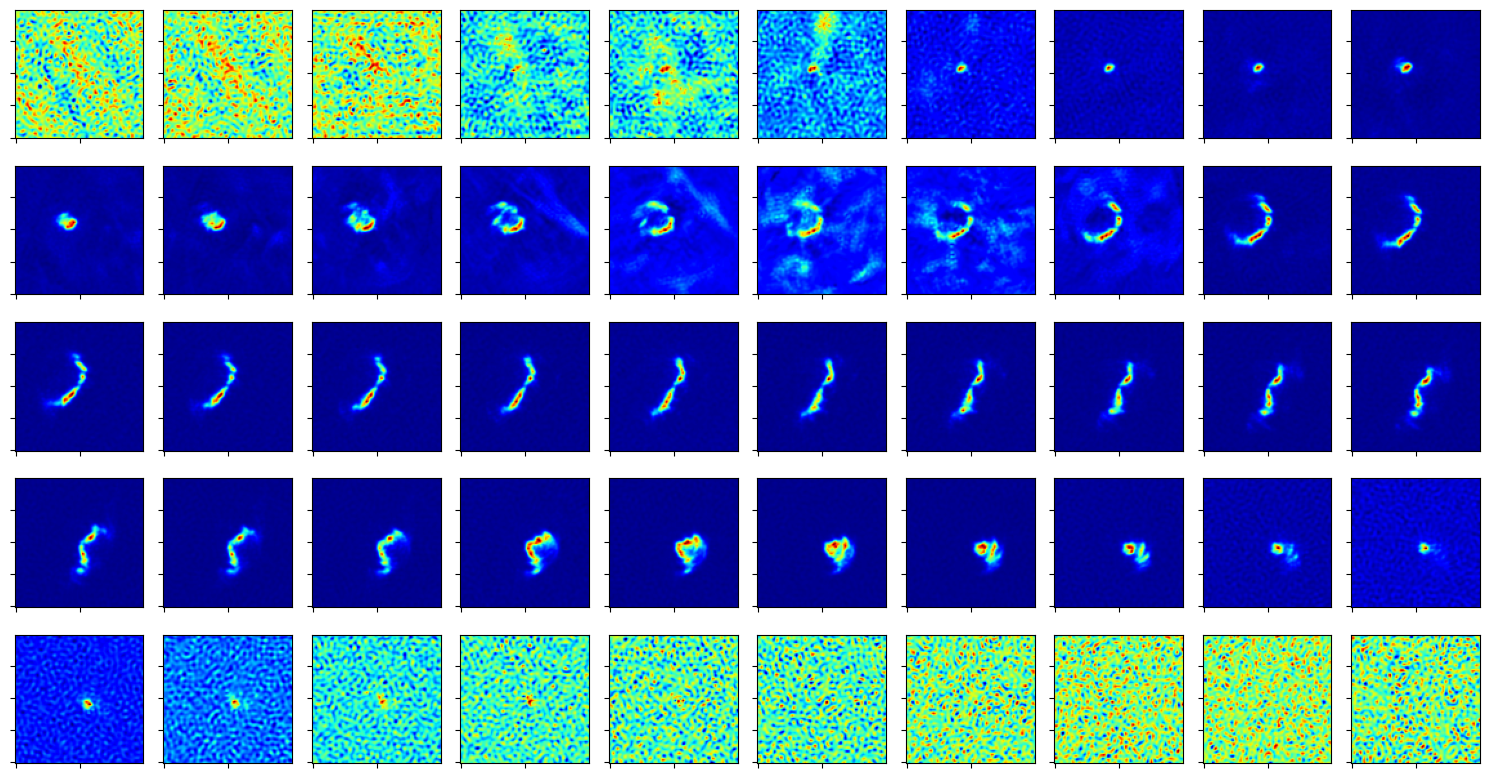

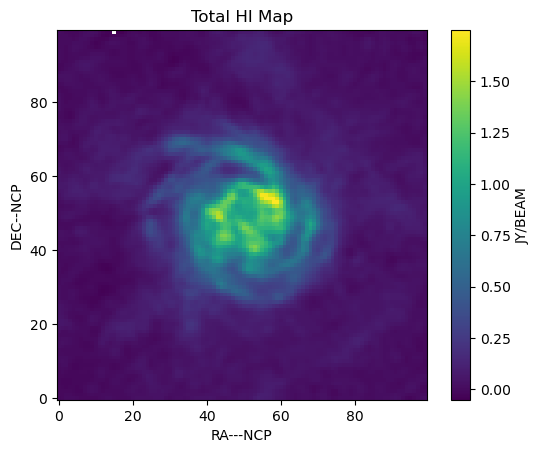

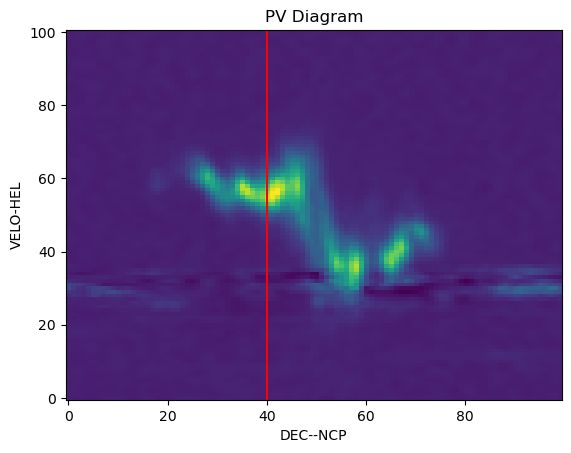

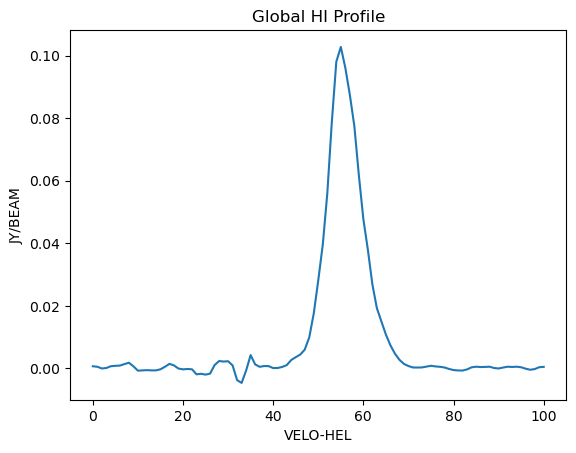

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

hdul = fits.open('ngc6946.fits')
data = hdul[0].data

fig, axes = plt.subplots(5, 10, figsize=(15, 8))

indices = list(range(1, 101, 2))

for ax, i in zip(axes.flat, indices):
    ax.imshow(data[i], origin='lower', cmap='jet')
    ax.set_xticklabels([])
    ax.set_yticklabels([])

plt.tight_layout()
plt.show()

#If you add two channel maps you get a new map where each 
#pixel is the sum of the two maps. If you add all channel 
#maps (not the noisy ones), you get a so called total HI map.
hi_map = np.sum(data[20:80], axis=0)

header = hdul[0].header

plt.figure()
im = plt.imshow(hi_map, origin='lower', cmap='viridis')

plt.xlabel(header['CTYPE1'])
plt.ylabel(header['CTYPE2'])

cbar = plt.colorbar(im)
cbar.set_label(header['BUNIT'])

plt.title("Total HI Map")
plt.show()

#position velocity
pv_map = data[:, :, 50]   # (Z, Y)

plt.figure()
plt.imshow(pv_map, origin='lower', aspect='auto', cmap='viridis')

plt.xlabel(header['CTYPE2'])  #dec
plt.ylabel(header['CTYPE3'])  #velocity

#vertical line at Dec index 40
plt.axvline(x=40, color='red')

plt.title("PV Diagram")
plt.show()

#global HI spectral profile
profile = data[:, 40, 50]   # (Z)

plt.figure()
plt.plot(profile)

plt.xlabel(header['CTYPE3'])  # velocity/frequency
plt.ylabel(header['BUNIT'])

plt.title("Global HI Profile")
plt.show()

#The spectral profile is the intensity values along the vertical line in the PV map.

In [3]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

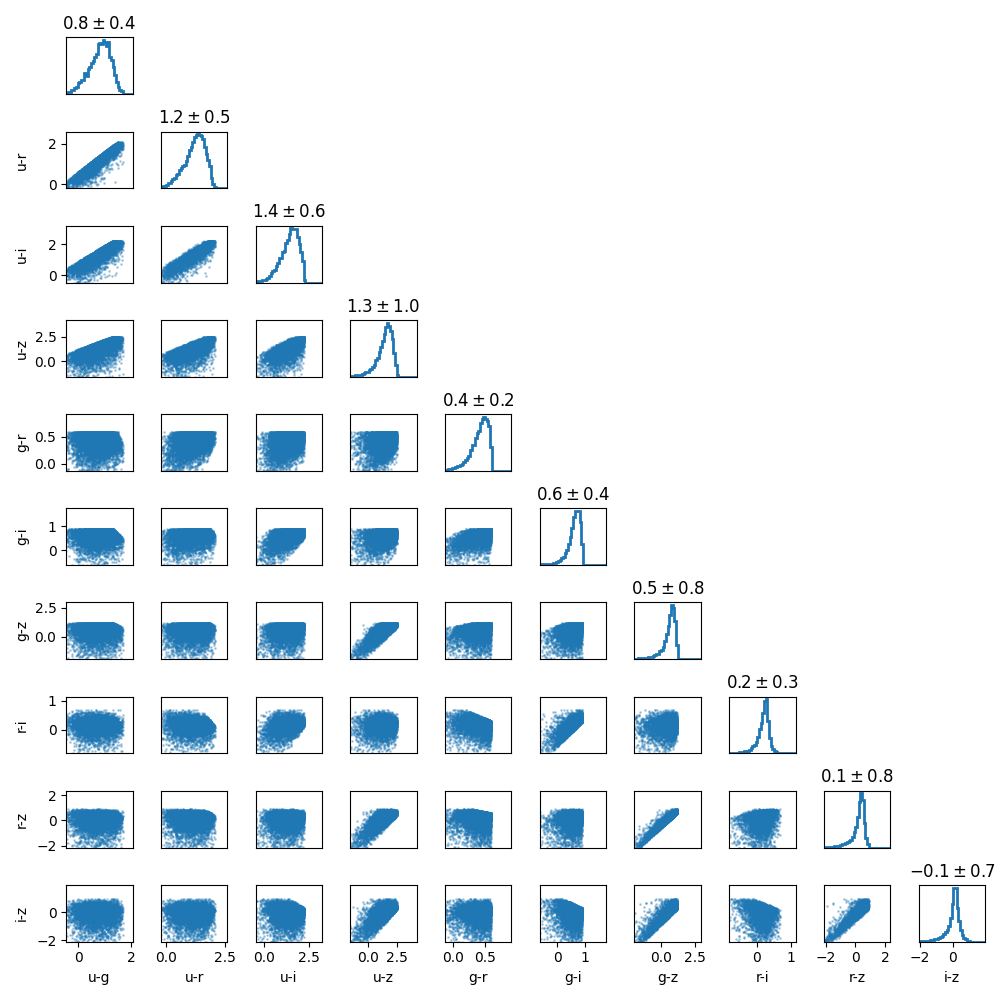
   
**Plot and answer**:

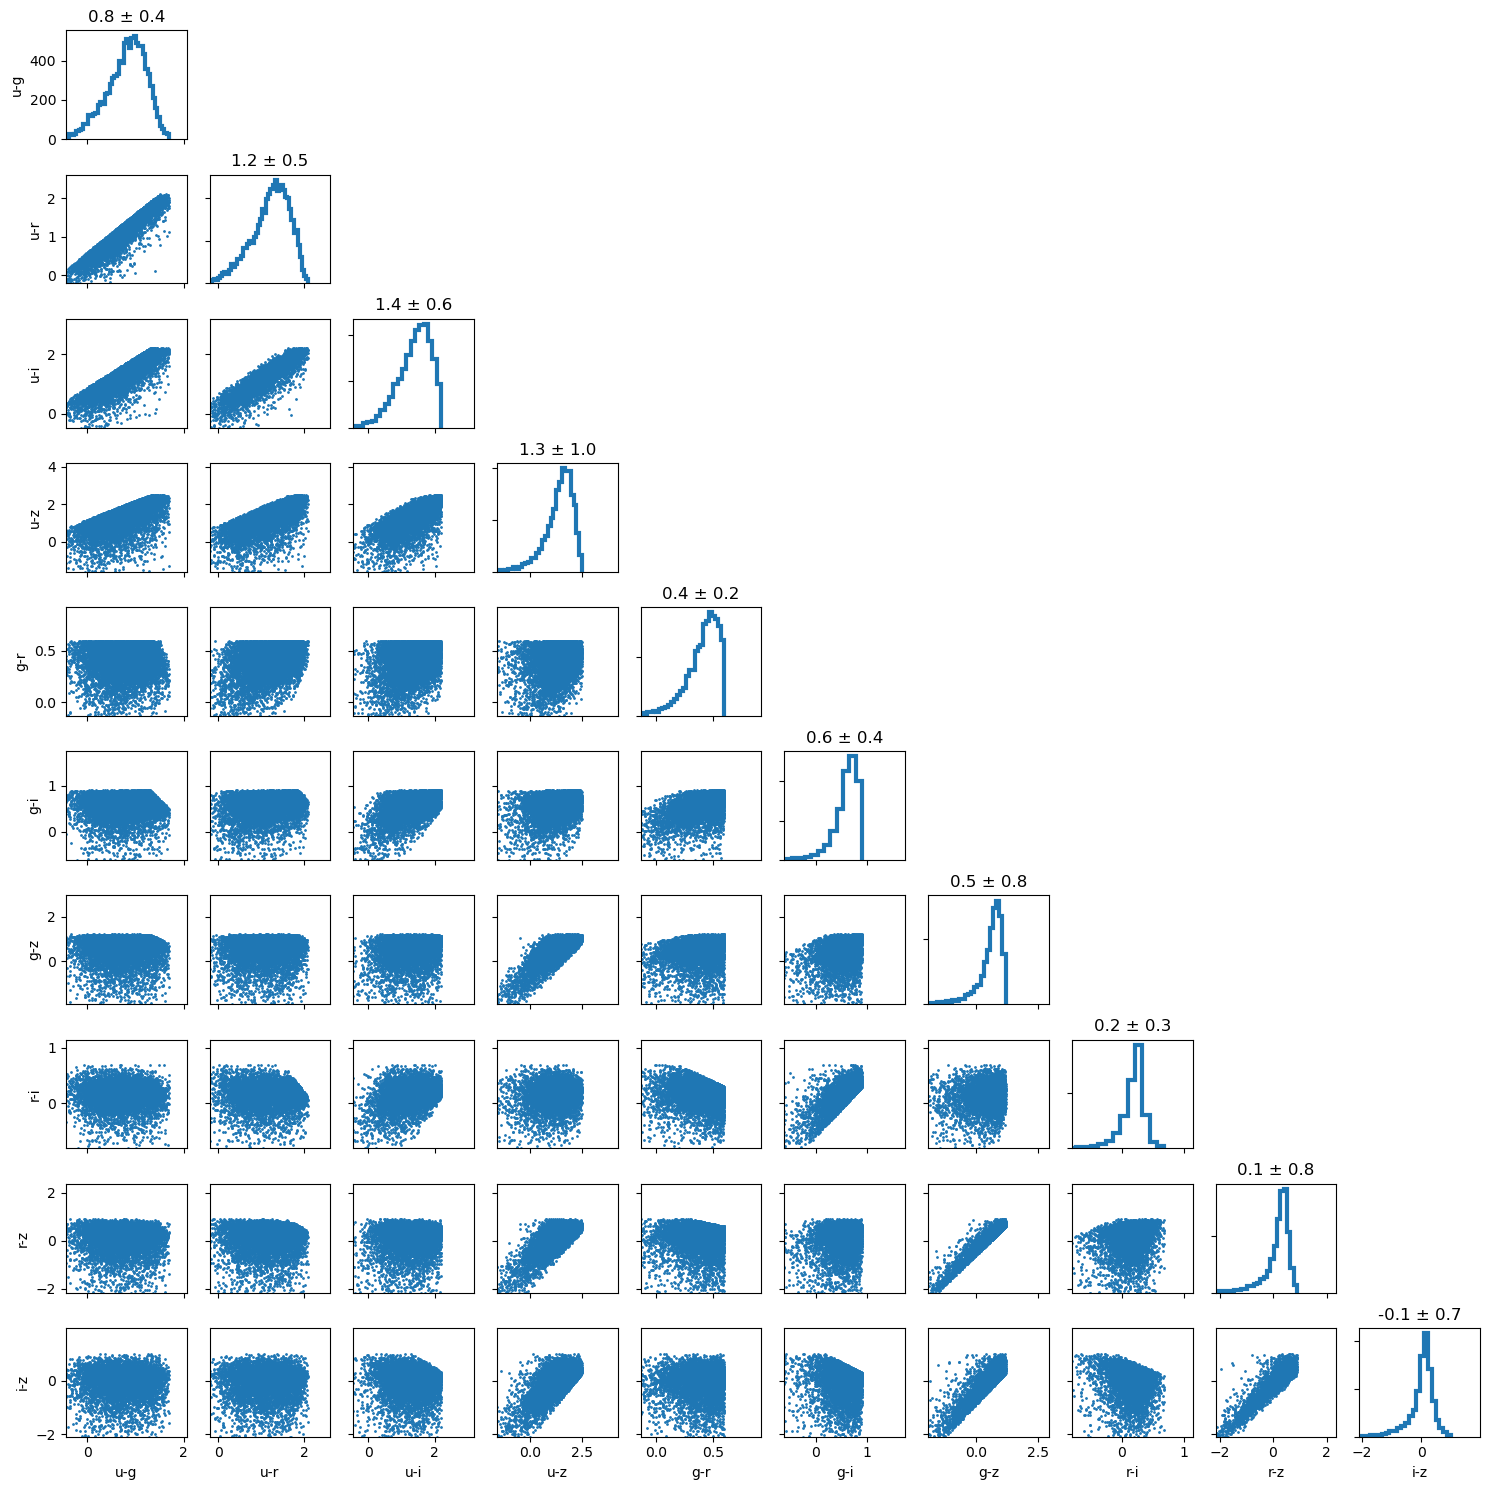

In [4]:
from astropy.io import fits
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

hdul = fits.open('SDSS_DR17_galaxies.fits')
data = hdul[1].data

df = pd.DataFrame(data) #the table

bands = ['u', 'g', 'r', 'i', 'z']

#filtering out negative data
mask = df['u'] > 0
mask &= df['g'] > 0
mask &= df['r'] > 0
mask &= df['i'] > 0
mask &= df['z'] > 0

df = df[mask]

#colours:
colours = {}

for i in range(len(bands)):
    for j in range(i+1, len(bands)):
        b1 = bands[i]
        b2 = bands[j]
        name = f"{b1}-{b2}"
        colours[name] = df[b1] - df[b2]

col_df = pd.DataFrame(colours)

#mean & std:
means = col_df.mean()
stds = col_df.std()

#object-oriented corner plot:

n = len(col_df.columns)

fig, axes = plt.subplots(n, n, figsize=(15, 15))

for i, col1 in enumerate(col_df.columns):
    for j, col2 in enumerate(col_df.columns):
        ax = axes[i, j]

        if j > i:
            ax.set_visible(False)
            continue

        if i == j:
            # histogram
            ax.hist(col_df[col1], bins=100, histtype='step', linewidth=3)

            mu = means[col1]
            sigma = stds[col1]

            ax.set_title(f"{mu:.1f} ± {sigma:.1f}")

            ax.set_xlim(mu - 3*sigma, mu + 3*sigma)

        else:
            # scatter plot
            ax.scatter(col_df[col2], col_df[col1], s=1)

            ax.set_xlim(means[col2] - 3*stds[col2],
                        means[col2] + 3*stds[col2])

            ax.set_ylim(means[col1] - 3*stds[col1],
                        means[col1] + 3*stds[col1])

        # clean up labels
        if i == n - 1:
            ax.set_xlabel(col2)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(col1)
        else:
            ax.set_yticklabels([])

plt.tight_layout()
plt.show()

In [5]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

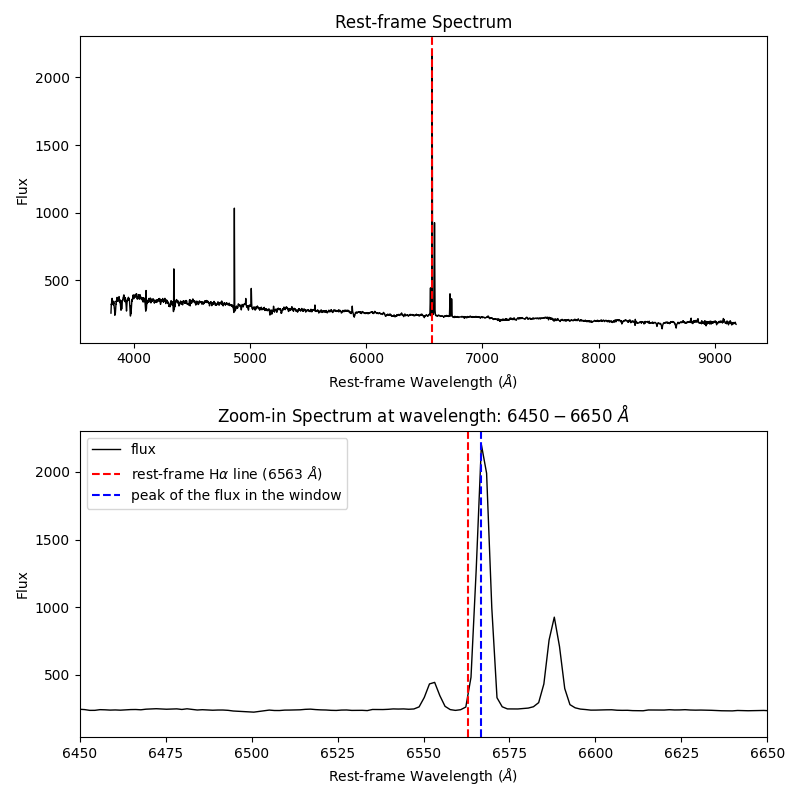

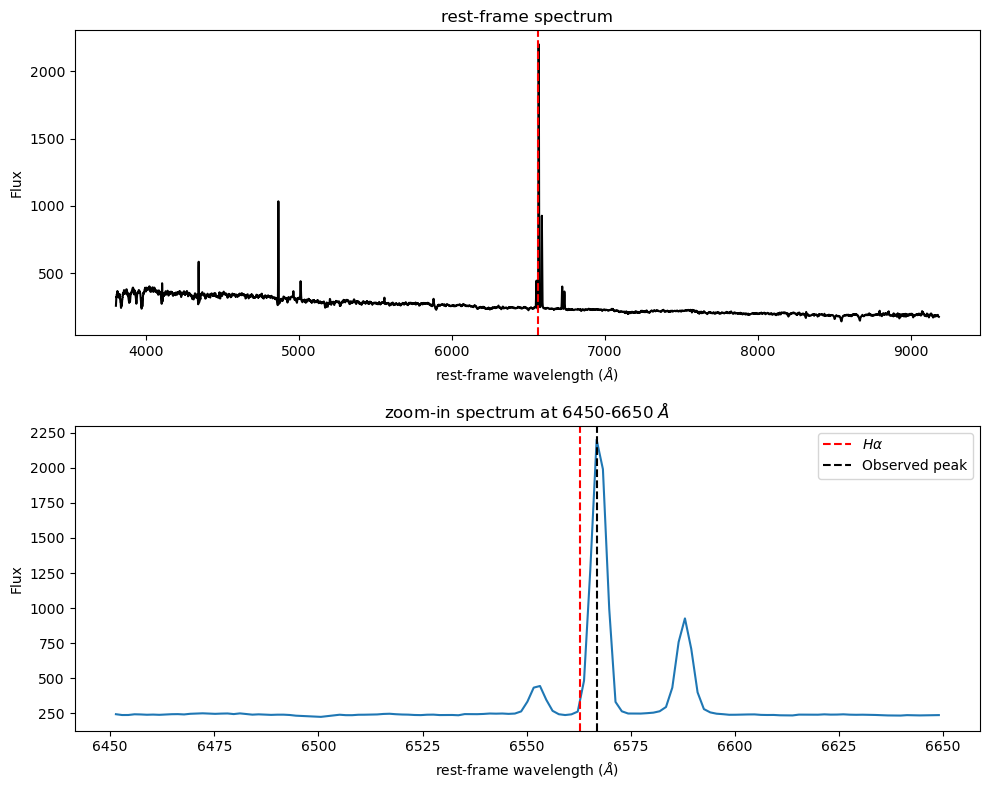

182.17918


In [6]:
from astropy import coordinates as coords
from astropy import units as u
from astroquery.sdss import SDSS
import matplotlib.pyplot as plt
import numpy as np


# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")

z = 0.0038
H_alpha = 6562.8


xid = SDSS.query_region(pos, radius=10*u.arcsec, spectro=True)
spec = SDSS.get_spectra(matches=xid)

#wavelength & flux
data = spec[0][1].data 

flux = data['flux']
loglam = data['loglam']
lam = 10**loglam   # convert log wavelength → linear

#redshift
lam_rest = lam / (1 + z)

mask = (lam_rest > 6450) & (lam_rest < 6650)

#plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=False)
#rest-frame
ax1.plot(lam_rest, flux, color='black')
ax1.set_title("rest-frame spectrum")
ax1.set_xlabel("rest-frame wavelength $(\AA)$")
ax1.set_ylabel("Flux")
#zoom-in
ax2.plot(lam_rest[mask], flux[mask])
ax2.set_title(r"zoom-in spectrum at 6450-6650 $\AA$")
ax2.set_xlabel("rest-frame wavelength $(\AA)$")
ax2.set_ylabel("Flux")

ax1.axvline(H_alpha, color='r', linestyle='--', label=r'$H \alpha$')
ax2.axvline(H_alpha, color='r', linestyle='--', label=r'$H \alpha$')

peak_idx = np.argmax(flux[mask])
peak_wave = lam_rest[mask][peak_idx]

ax2.axvline(peak_wave, color='k', linestyle='--', label='Observed peak')
ax2.legend()

plt.tight_layout()
plt.show()

c = 3e5  # km/s
v = c * (peak_wave - H_alpha) / H_alpha
print(v)

In [7]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

In [8]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval


hdul = fits.open('20210422_Li_.00000066.FIT')
image = hdul[0].data

scales = ['no scale', 'linear', 'sinh', 'log', 'power', 'sqrt', 'squared', 'hist']

def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='grey',
              **kwargs):
    
    """
imdisplay visualises FITS images with different stretches (linear, logarithmic, 
square root, power-law, histogram equalisation) and Z-scale normalization.

Parameters
----------
data : 2D array
    Input image data (e.g. FITS frame).

ax : matplotlib.axes.Axes
    Matplotlib axis on which the image is plotted.

vmin, vmax : float or None, optional
    Minimum and maximum intensity values for display scaling.
    If None, they are estimated automatically using percentiles or Z-scale.

percentlow : float, optional
    Lower percentile for automatic contrast scaling (default is 1).

percenthigh : float, optional
    Upper percentile for automatic contrast scaling (default is 99).

zscale : bool, optional
    If True, uses ZScaleInterval for dynamic range estimation.

scale : str, optional
    Intensity stretch method. Options:
    - 'linear' : linear scaling
    - 'sinh'   : hyperbolic sine stretch
    - 'log'    : logarithmic stretch
    - 'power'  : power-law stretch
    - 'sqrt'   : square root stretch
    - 'squared': squared intensity stretch
    - 'hist'   : histogram equalisation stretch

power : float, optional
    Exponent used for power-law scaling (default is 1.5).

cmap : str, optional
    Colormap used for display (default is 'grey').

**kwargs :
    Additional arguments passed to matplotlib.imshow().

Returns
-------
matplotlib.image.AxesImage
    The image object returned by imshow.
"""
    
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()
        
    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

axes[0].imshow(image, origin='lower', cmap='bone')
axes[0].set_title("no scale", fontsize=10)
axes[0].set_xticks([])
axes[0].set_yticks([])

for ax, scale in zip(axes[1:], scales):
    imdisplay(image, ax=ax, scale=scale, cmap='bone', zscale=True)
    ax.set_title(scale, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

axes[-1].axis('off')

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '20210422_Li_.00000066.FIT'

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

In [9]:
from pathlib import Path

datadir = "/Users/users/zeleszek/PROGNUM-repo/PROGNUM_2026/Task6/DATA"  
excludes = ['BIAS', 'FLAT', 'DARK']  # Exclude these images if these are opart of the file name

path = Path(datadir)
filepaths = []
for filepath in path.iterdir():
    if filepath.suffix.lower() in ['.fits', '.fit', '.fts']:
        if not any(ext in filepath.name for ext in excludes):
            filepaths.append(filepath)

# Print first 5 file names
for f in filepaths[:5]:
    print(f.name)

160913_Li_00000023.fits
160913_Li_00000024.fits
160913_Li_00000025.fits
160913_Li_00000026.fits
160913_Li_00000027.fits


In [10]:
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval


def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)

<function matplotlib.pyplot.show(close=None, block=None)>

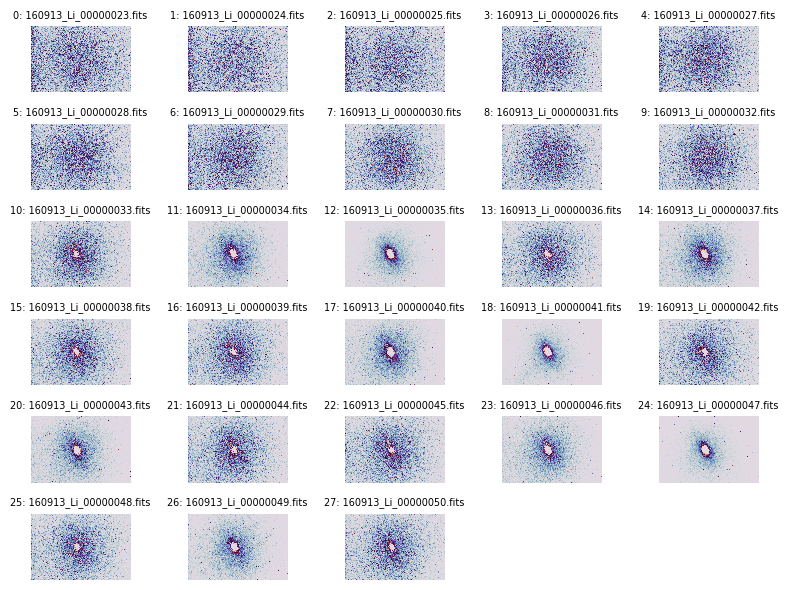

In [11]:
from matplotlib.pyplot import figure, show
from astropy.io import fits
from math import ceil

fig = figure(figsize=(8,6), tight_layout=True)
count = 1
ncols = 5
nrows = ceil(len(filepaths)/ncols)
for i, filepath in enumerate(filepaths):
    hdulist = fits.open(filepath)
    ax = fig.add_subplot(nrows, ncols, count)
    ax.axis('off')
    imdisplay(hdulist[0].data, ax, scale='power', power=3, cmap='twilight')
    ax.set_title(f"{i}: {filepath.name}", fontsize=7)
    count += 1
    hdulist.close()
show #doesn't seem to be the need to exclude any

In [12]:
images = []
for filepath in filepaths:
    hdulist = fits.open(filepath)
    images.append(hdulist[0].data.astype('float'))
    hdulist.close()

datacube = np.stack(images)
print(f"Shape of data cube with stacked images: {datacube.shape}")

stacked_images = np.median(datacube, axis=0)
print(f"Shape of median image: {stacked_images.shape}")
print(f"Type of the data: {stacked_images.dtype}")
print(f"Mean of the data in the median image: {stacked_images.mean()}")

Shape of data cube with stacked images: (28, 2048, 3072)
Shape of median image: (2048, 3072)
Type of the data: float64
Mean of the data in the median image: 2576.4255842367807


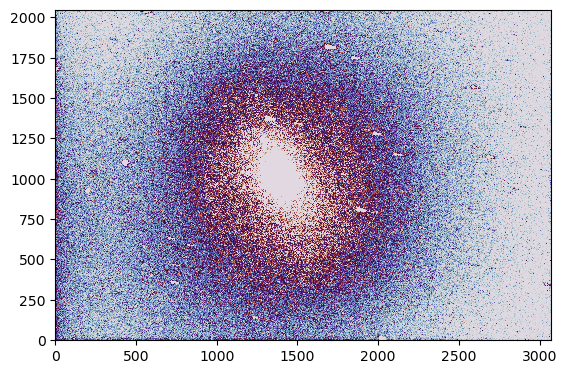

In [13]:
from matplotlib.pyplot import subplots, show

fig, ax = subplots()
imdisplay(stacked_images, ax, percentlow=5, percenthigh=95, scale='squared', cmap='twilight')
show()

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")